In [1]:
!pip install polars catboost

In [2]:
import polars as pl
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt

In [3]:
from catboost import Pool, CatBoostClassifier
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import KFold

Следующий блок добавлен на случай, если у вас проблемы с версиями polars, catboost, или в целом с .parquet файлами.

В случае конфликта версий catboost и polars при создании Pool, может потребоваться использовать fallback функцию to_pandas(). Более нигде pandas далее не используется.

In [4]:
try:
    import pyarrow
    print("PyArrow is installed. Version:", pyarrow.__version__)
except ModuleNotFoundError:
    print("PyArrow is NOT found in this environment. You installed it in a different one.")

PyArrow is NOT found in this environment. You installed it in a different one.


### Часть 1, смотрим данные

Сперва подгрузим данные и посмотрим с чем нам предстоит работать.

Участникам предоставляются 2 пары файлов с признаками (train и test):

1. train_main_features.parquet + test_main_features.parquet (199 признаков + ключ)
2. train_extra_features.parquet + test_extra_features.parquet (2241 признак + ключ)

##### Часть 1.1 данные признаков

Попробуем сперва поработать с первым набором (*_main_features.parquet*).

In [5]:
!wget https://storage.yandexcloud.net/data-fusion-2026/2%20CyberShelf/train_main_features.parquet
!wget https://storage.yandexcloud.net/data-fusion-2026/2%20CyberShelf/test_main_features.parquet
!wget https://storage.yandexcloud.net/data-fusion-2026/2%20CyberShelf/train_target.parquet
!wget https://storage.yandexcloud.net/data-fusion-2026/2%20CyberShelf/sample_submit.parquet

zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget
zsh:1: command not found: wget


In [6]:
!ls

%D0%92%D0%B0%D0%BB%D0%B8%D0%B5%D0%B2_%D0%94%D0%B8%D0%BD%D0%B0%D1%80 (1).pdf
%D0%92%D0%B0%D0%BB%D0%B8%D0%B5%D0%B2_%D0%94%D0%B8%D0%BD%D0%B0%D1%80.pdf
%D0%92%D0%B0%D0%BB%D0%B8%D0%B5%D0%B2_%D0%94%D0%B8%D0%BD%D0%B0%D1%80_%D0%94%D0%B8%D0%BB%D1%8C%D1%84%D0%B0%D1%81%D0%BE%D0%B2%D0%B8%D1%87.docx.pdf
-4-22-2025.png
00_binary_classifier_logreg (1).ipynb
00_binary_classifier_logreg.ipynb
01_261034_126.xlsx
01_binary_classifier_svm_tree.ipynb
02_multiclass_one-hot (1).ipynb
02_multiclass_one-hot.ipynb
03_split_crossval (1).ipynb
03_split_crossval.ipynb
03b623ae-f1b7-4e57-a351-605b24a81592.docx
04_regression.ipynb
05_clustering.ipynb
06_scatter_matrix (1).ipynb
06_scatter_matrix.ipynb
09_plotly.ipynb
0a18ab.txt
1-2_ValievDD (1).sql
1-2_ValievDD (2).sql
1-2_ValievDD.sql
1. Big O.pdf
1.jpg
1.png
1010 - see.mp3
1010xЛехаМедь - зуб.wav
112.1.pdf
123 спорт.docx
123.MOV
124.mp4
1243123.xlsx
1288635.ppt
1579e1.txt
1697485186_klev-club-p-kartinki-ulitsa-s-lyudmi-22.jpg
1720431930tbank.png
175354999643263369

In [7]:
train = pl.read_parquet('train_main_features.parquet')
test = pl.read_parquet('test_main_features.parquet')

In [8]:
print('Тренировочные данные:', train.shape)
print('Тестовые данные:', test.shape)
train.head(n = 5)

Тренировочные данные: (750000, 200)
Тестовые данные: (250000, 200)


customer_id,cat_feature_1,cat_feature_2,cat_feature_3,cat_feature_4,cat_feature_5,cat_feature_6,cat_feature_7,cat_feature_8,cat_feature_9,cat_feature_10,cat_feature_11,cat_feature_12,cat_feature_13,cat_feature_14,cat_feature_15,cat_feature_16,cat_feature_17,cat_feature_18,cat_feature_19,cat_feature_20,cat_feature_21,cat_feature_22,cat_feature_23,cat_feature_24,cat_feature_25,cat_feature_26,cat_feature_27,cat_feature_28,cat_feature_29,cat_feature_30,cat_feature_31,cat_feature_32,cat_feature_33,cat_feature_34,cat_feature_35,cat_feature_36,…,num_feature_96,num_feature_97,num_feature_98,num_feature_99,num_feature_100,num_feature_101,num_feature_102,num_feature_103,num_feature_104,num_feature_105,num_feature_106,num_feature_107,num_feature_108,num_feature_109,num_feature_110,num_feature_111,num_feature_112,num_feature_113,num_feature_114,num_feature_115,num_feature_116,num_feature_117,num_feature_118,num_feature_119,num_feature_120,num_feature_121,num_feature_122,num_feature_123,num_feature_124,num_feature_125,num_feature_126,num_feature_127,num_feature_128,num_feature_129,num_feature_130,num_feature_131,num_feature_132
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1000001,1.0,0.0,2.0,1.0,2.0,3.0,2.0,2.0,4.0,2.0,0.0,0.0,0.0,1.0,2.0,0.0,2.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,1.0,2.0,1.0,2.0,2.0,0.0,0.0,212.0,0.0,0.0,…,-0.284519,null,-0.004499,null,-0.050159,-0.002297,-0.043592,-0.061488,0.450342,null,0.0,null,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,null,-0.493959,-0.019079,null,null,null,null,-0.001357,-0.031281,-0.046146,null,-0.445279,null,null,-0.107666,-0.418616,null,null
1000002,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,212.0,1.0,0.0,…,-0.284519,0.460275,-0.004278,null,-0.556244,-0.002297,-0.043592,-0.061488,1.998252,-0.009552,0.0,-0.005762,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.256445,-0.014154,null,-0.24167,null,null,-0.001357,-0.031281,-0.046146,-0.10217,1.550722,null,null,-0.170724,-0.805771,-0.397803,-0.373734
1000003,1.0,0.0,0.0,1.0,0.0,3.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,212.0,0.0,0.0,…,-0.284519,-0.264397,-0.004278,null,null,-0.002297,-0.043592,-0.061488,-0.264078,null,0.0,-0.26649,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.57313,-0.019124,null,-0.24167,null,null,-0.001357,-0.031281,-0.046146,null,-0.475778,null,null,-0.170724,-0.602005,-0.397803,-0.373734
1000004,1.0,0.0,2.0,1.0,2.0,3.0,2.0,2.0,3.0,2.0,0.0,0.0,0.0,1.0,2.0,2.0,2.0,2.0,2.0,0.0,0.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,1.0,2.0,2.0,0.0,0.0,212.0,0.0,0.0,…,-0.284519,null,-0.004499,null,null,-0.002297,-0.043592,-0.061488,0.688482,-0.009552,0.0,null,-0.060492,null,null,-0.429813,null,-0.009654,-0.293036,null,-0.57313,null,null,-0.505441,null,0.714631,-0.001357,-0.031281,-0.046146,null,-0.475778,0.111196,0.116695,null,-0.724265,null,null
1000005,1.0,2.0,0.0,1.0,0.0,3.0,0.0,0.0,2.0,1.0,2.0,2.0,2.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,2.0,2.0,0.0,2.0,2.0,2.0,2.0,0.0,0.0,0.0,0.0,2.0,2.0,212.0,2.0,2.0,…,-0.284519,-0.264397,-0.004499,null,null,-0.002297,-0.043592,null,-0.264078,null,0.0,-0.26649,null,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.57313,-0.018674,null,null,null,null,null,null,-0.046146,null,null,null,null,-0.107666,null,-0.397803,-0.373734


In [9]:
# Информацию о наличии каждого продукта требуется классифицровать по отдельности, в рамках multi-label постановки.
target = pl.read_parquet('train_target.parquet')
target.head(n = 5)

customer_id,target_1_1,target_1_2,target_1_3,target_1_4,target_1_5,target_2_1,target_2_2,target_2_3,target_2_4,target_2_5,target_2_6,target_2_7,target_2_8,target_3_1,target_3_2,target_3_3,target_3_4,target_3_5,target_4_1,target_5_1,target_5_2,target_6_1,target_6_2,target_6_3,target_6_4,target_6_5,target_7_1,target_7_2,target_7_3,target_8_1,target_8_2,target_8_3,target_9_1,target_9_2,target_9_3,target_9_4,target_9_5,target_9_6,target_9_7,target_9_8,target_10_1
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1000001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1000002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1000003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1000004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1000005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [10]:
target_columns = [col for col in target.columns if col.startswith("target")]
# Только колонки таргета
# for col in target_columns:
#     print(target[col].unique().sort())

In [11]:
# Т.к. все таргеты представлены 1 и 0 можно их заменить на Int8
target = target.with_columns(
    pl.col(target_columns).cast(pl.Int8)
)

Легенда гласит, что в данных достаточно много пропусков.

Так ли это?

Нам также известно, что часть признаков в данных — категориальная.
По легенде их можно найти по названиям "cat_feature".

Эти категориальные признаки стоит отдельно выделить и сохранить для Catboost.

In [12]:
cat_feature_names = [
    col_name for col_name in train.columns
    if col_name.startswith("cat_feature")
]
train = train.with_columns(
    pl.col(cat_feature_names).cast(pl.Int32)
)
train = train.with_columns(
    pl.col(pl.Float64).cast(pl.Float32),
    pl.col(pl.Int64).cast(pl.Int32)
)

In [13]:
train.head(n= 5)

customer_id,cat_feature_1,cat_feature_2,cat_feature_3,cat_feature_4,cat_feature_5,cat_feature_6,cat_feature_7,cat_feature_8,cat_feature_9,cat_feature_10,cat_feature_11,cat_feature_12,cat_feature_13,cat_feature_14,cat_feature_15,cat_feature_16,cat_feature_17,cat_feature_18,cat_feature_19,cat_feature_20,cat_feature_21,cat_feature_22,cat_feature_23,cat_feature_24,cat_feature_25,cat_feature_26,cat_feature_27,cat_feature_28,cat_feature_29,cat_feature_30,cat_feature_31,cat_feature_32,cat_feature_33,cat_feature_34,cat_feature_35,cat_feature_36,…,num_feature_96,num_feature_97,num_feature_98,num_feature_99,num_feature_100,num_feature_101,num_feature_102,num_feature_103,num_feature_104,num_feature_105,num_feature_106,num_feature_107,num_feature_108,num_feature_109,num_feature_110,num_feature_111,num_feature_112,num_feature_113,num_feature_114,num_feature_115,num_feature_116,num_feature_117,num_feature_118,num_feature_119,num_feature_120,num_feature_121,num_feature_122,num_feature_123,num_feature_124,num_feature_125,num_feature_126,num_feature_127,num_feature_128,num_feature_129,num_feature_130,num_feature_131,num_feature_132
i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,…,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32
1000001,1,0,2,1,2,3,2,2,4,2,0,0,0,1,2,0,2,2,2,0,0,0,2,0,0,0,1,2,1,2,2,0,0,212,0,0,…,-0.284519,null,-0.004499,null,-0.050159,-0.002297,-0.043592,-0.061488,0.450342,null,0.0,null,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,null,-0.493959,-0.019079,null,null,null,null,-0.001357,-0.031281,-0.046146,null,-0.445279,null,null,-0.107666,-0.418616,null,null
1000002,1,0,0,1,0,3,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,1,0,212,1,0,…,-0.284519,0.460275,-0.004278,null,-0.556244,-0.002297,-0.043592,-0.061488,1.998252,-0.009552,0.0,-0.005762,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.256445,-0.014154,null,-0.24167,null,null,-0.001357,-0.031281,-0.046146,-0.10217,1.550722,null,null,-0.170724,-0.805771,-0.397803,-0.373734
1000003,1,0,0,1,0,3,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,1,0,0,0,0,0,0,212,0,0,…,-0.284519,-0.264397,-0.004278,null,null,-0.002297,-0.043592,-0.061488,-0.264078,null,0.0,-0.26649,-0.060492,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.57313,-0.019124,null,-0.24167,null,null,-0.001357,-0.031281,-0.046146,null,-0.475778,null,null,-0.170724,-0.602005,-0.397803,-0.373734
1000004,1,0,2,1,2,3,2,2,3,2,0,0,0,1,2,2,2,2,2,0,0,2,2,0,0,0,0,2,1,2,2,0,0,212,0,0,…,-0.284519,null,-0.004499,null,null,-0.002297,-0.043592,-0.061488,0.688482,-0.009552,0.0,null,-0.060492,null,null,-0.429813,null,-0.009654,-0.293036,null,-0.57313,null,null,-0.505441,null,0.714631,-0.001357,-0.031281,-0.046146,null,-0.475778,0.111196,0.116695,null,-0.724265,null,null
1000005,1,2,0,1,0,3,0,0,2,1,2,2,2,0,1,0,0,0,0,2,2,2,0,2,2,2,2,0,0,0,0,2,2,212,2,2,…,-0.284519,-0.264397,-0.004499,null,null,-0.002297,-0.043592,null,-0.264078,null,0.0,-0.26649,null,-0.279105,null,-0.429813,null,-0.009654,-0.293036,-0.004421,-0.57313,-0.018674,null,null,null,null,null,null,-0.046146,null,null,null,null,-0.107666,null,-0.397803,-0.373734


## Аналитика Датасета

Для начала посмотрим процент пропусков в нашем датасете

In [14]:
# Процент пропусков по каждой колонке
null_stats = (
    train.null_count()
    .unpivot(variable_name='Column', value_name='Nulls')
    .with_columns(
        (pl.col('Nulls') / len(train) * 100).alias('Null_%')
    )
    .sort('Null_%', descending=True)
)

In [18]:
# Визуализация топ-30 колонок с пропусками
top_nulls = null_stats.to_pandas()
top_nulls

ModuleNotFoundError: No module named 'pyarrow'

Есть колонки в которых свыше 90% строк являются пропусками, скорее всего это данные которые относятся к какому то не популярному продукту

In [20]:
cat_cols = [c for c in train.columns if c.startswith('cat_feature')]
for col in cat_cols:
    print(f"{col}: unique={train[col].n_unique()}, nulls={train[col].null_count()}")

cat_feature_1: unique=2, nulls=0
cat_feature_2: unique=3, nulls=0
cat_feature_3: unique=3, nulls=0
cat_feature_4: unique=2, nulls=0
cat_feature_5: unique=3, nulls=0
cat_feature_6: unique=4, nulls=0
cat_feature_7: unique=3, nulls=0
cat_feature_8: unique=3, nulls=0
cat_feature_9: unique=5, nulls=0
cat_feature_10: unique=3, nulls=0
cat_feature_11: unique=3, nulls=0
cat_feature_12: unique=3, nulls=0
cat_feature_13: unique=3, nulls=0
cat_feature_14: unique=2, nulls=0
cat_feature_15: unique=3, nulls=0
cat_feature_16: unique=3, nulls=0
cat_feature_17: unique=3, nulls=0
cat_feature_18: unique=3, nulls=0
cat_feature_19: unique=3, nulls=0
cat_feature_20: unique=3, nulls=0
cat_feature_21: unique=3, nulls=0
cat_feature_22: unique=3, nulls=0
cat_feature_23: unique=3, nulls=0
cat_feature_24: unique=3, nulls=0
cat_feature_25: unique=3, nulls=0
cat_feature_26: unique=3, nulls=0
cat_feature_27: unique=3, nulls=0
cat_feature_28: unique=3, nulls=0
cat_feature_29: unique=2, nulls=0
cat_feature_30: unique=

В основном многие кат колонки имеют 3 категории, самые большое кол-во классов 39 признаке - 1989

In [21]:
train['cat_feature_39'].value_counts(sort = True)

cat_feature_39,count
i32,u32
2141,585646
0,1965
1,1000
2,845
3,693
…,…
1913,1
2137,1
1881,1


Видно что категория 2141 доминирует и составляет 78% всех других категорий

In [22]:
data = []

for col in target_columns:
    vc = target[col].value_counts()
    n_pos = vc.filter(pl.col(col) == 1).select("count").item() if 1 in vc[col] else 0

    data.append({
        "feature": col,
        "positive_count": n_pos,
        "positive_pct": round(n_pos / len(target) * 100, 2),
        "neg_pos_ratio": round((len(target) - n_pos) / n_pos, 1) if n_pos > 0 else float('inf')
    })

target_ratio = pl.DataFrame(data).sort("positive_count", descending=True)
del data

In [23]:
with pl.Config(tbl_rows=200, tbl_cols=40):
    print(target_ratio)

shape: (41, 4)
┌─────────────┬────────────────┬──────────────┬───────────────┐
│ feature     ┆ positive_count ┆ positive_pct ┆ neg_pos_ratio │
│ ---         ┆ ---            ┆ ---          ┆ ---           │
│ str         ┆ i64            ┆ f64          ┆ f64           │
╞═════════════╪════════════════╪══════════════╪═══════════════╡
│ target_10_1 ┆ 236289         ┆ 31.51        ┆ 2.2           │
│ target_9_6  ┆ 167304         ┆ 22.31        ┆ 3.5           │
│ target_8_1  ┆ 76872          ┆ 10.25        ┆ 8.8           │
│ target_3_1  ┆ 73780          ┆ 9.84         ┆ 9.2           │
│ target_3_2  ┆ 73057          ┆ 9.74         ┆ 9.3           │
│ target_9_7  ┆ 57936          ┆ 7.72         ┆ 11.9          │
│ target_7_1  ┆ 46875          ┆ 6.25         ┆ 15.0          │
│ target_9_2  ┆ 27337          ┆ 3.64         ┆ 26.4          │
│ target_8_2  ┆ 24397          ┆ 3.25         ┆ 29.7          │
│ target_7_2  ┆ 20754          ┆ 2.77         ┆ 35.1          │
│ target_2_2  ┆ 19009    

Проблемы таргеты: \
target_1_3  , target_1_4, target_8_3, target_9_3, target_9_8, target_1_1, target_5_1, target_6_1, target_4_1, target_6_4, target_2_4, target_6_2, target_2_1, target_9_5, target_6_3, target_2_6, target_7_3, target_9_1, target_1_2, target_5_2, target_3_4, target_9_4, target_2_5, target_1_5, target_3_5, target_2_3, target_3_3, target_6_5, target_2_7, target_2_8

Эти таргеты встречаются редко, поэтому важно определить из за какого признака они сильнее всего зависят


In [24]:
# объеденяем наши таргеты с признаками
train_with_target = train.join(
    target.select(['customer_id'] + target_columns),
    on='customer_id',
    how='left'
)

In [25]:
# Считаем средние для обеих групп
mean_2141 = (
    train_with_target
    .filter(pl.col('cat_feature_39') == 2141)
    .select(target_columns)
    .mean()
    .unpivot(variable_name='Target', value_name='Mean_2141')
)

mean_others = (
    train_with_target
    .filter(pl.col('cat_feature_39') != 2141)
    .select(target_columns)
    .mean()
    .unpivot(variable_name='Target', value_name='Mean_others')
)


In [26]:
# Объединяем
comparison = mean_2141.join(mean_others, on='Target').with_columns(
    (pl.col('Mean_2141') - pl.col('Mean_others')).alias('Difference')
).to_pandas()

# График
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# График 1 — сравнение средних
x = range(len(comparison))
axes[0].bar([i - 0.2 for i in x], comparison['Mean_2141'],
            width=0.4, label='Категория 2141', color='steelblue')
axes[0].bar([i + 0.2 for i in x], comparison['Mean_others'],
            width=0.4, label='Остальные', color='orange')
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison['Target'], rotation=90, fontsize=8)
axes[0].set_title('Среднее значение таргетов по группам')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# График 2 — разница между группами
colors = ['green' if d > 0 else 'red' for d in comparison['Difference']]
axes[1].bar(x, comparison['Difference'], color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison['Target'], rotation=90, fontsize=8)
axes[1].set_title('Разница средних (2141 - остальные)')
axes[1].axhline(y=0, color='black', linewidth=0.5)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Таблица с топ различиями
print("\nТаргеты где разница наибольшая:")
print(
    comparison[['Target', 'Mean_2141', 'Mean_others', 'Difference']]
    .reindex(comparison['Difference'].abs().sort_values(ascending=False).index)
    .head(10)
    .to_string(index=False)
)

ModuleNotFoundError: No module named 'pyarrow'

target_1_3  , target_1_4, target_8_3, target_9_3, target_9_8, target_1_1, target_5_1, target_6_1, target_4_1, target_6_4, target_2_4, target_6_2, target_2_1, target_9_5, target_6_3, target_2_6, target_7_3, target_9_1, target_1_2, target_5_2, target_3_4, target_9_4, target_2_5, target_1_5, target_3_5, target_2_3, target_3_3, target_6_5, target_2_7, target_2_8

In [27]:
comparison

NameError: name 'comparison' is not defined

In [28]:
# Не очень понятно поэтому будем испльзовать lift
# Глобальное среднее каждого таргета
mean_global = (
    train_with_target
    .select(target_columns)
    .mean()
    .unpivot(variable_name='Target', value_name='Mean_global')
)

comparison = (
    mean_2141
    .join(mean_others, on='Target')
    .join(mean_global, on='Target')
    .with_columns([
        # Lift — во сколько раз группа 2141 богаче позитивными
        (pl.col('Mean_2141') / pl.col('Mean_global')).alias('Lift_2141'),
        (pl.col('Mean_others') / pl.col('Mean_global')).alias('Lift_others'),
    ])
).to_pandas()

print(comparison[['Target', 'Mean_global', 'Lift_2141', 'Lift_others']]
      .sort_values('Lift_2141', ascending=False)
      .to_string(index=False))

ModuleNotFoundError: No module named 'pyarrow'

На таблице и экстремальные таргеты находятся на самом вверху ( Lift_2141 наибольший) либо в само низу (Lift_others наибольший).

##### Часть 1.2 целевые переменные

В задаче предоставлена информация о 41 банковском продукте.

In [29]:
# Давайте поверхностно посмотрим на то. с чем нам предстоит работать
target_col_means = (
    target.select(pl.col(target_columns).mean())
    .transpose(include_header = True, column_names = ["Mean"])
    .rename({"column": "Target"})
    #.sort("Sum", descending=True)
)

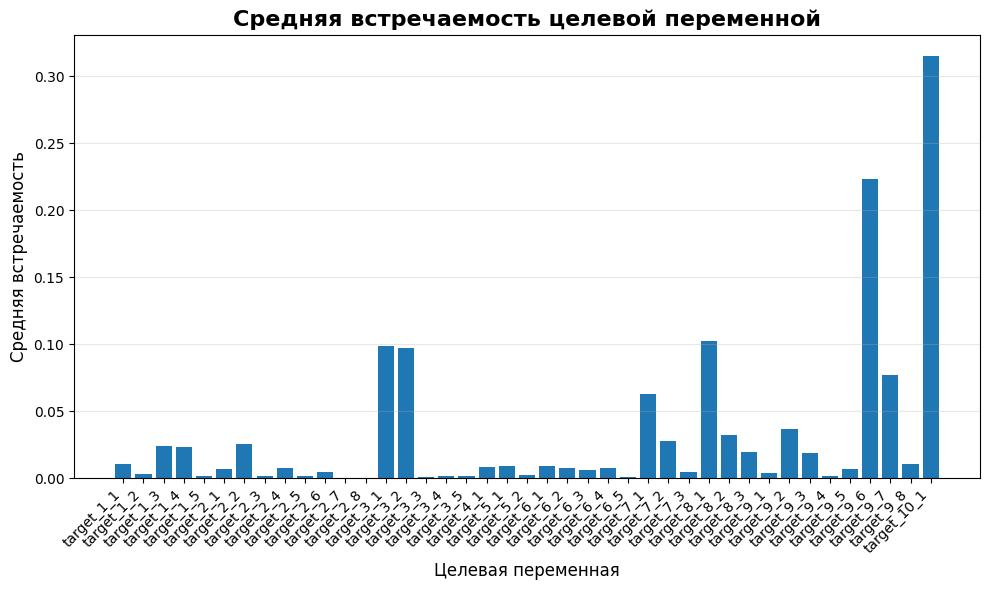

In [30]:
plt.figure(figsize = (10, 6))

bars = plt.bar(target_col_means["Target"], target_col_means["Mean"])

plt.title("Средняя встречаемость целевой переменной", fontsize = 16, fontweight='bold')
plt.xlabel("Целевая переменная", fontsize = 12)
plt.ylabel("Средняя встречаемость", fontsize = 12)
plt.xticks(rotation = 45, ha = 'right', fontsize = 10)
plt.grid(axis = 'y', alpha = 0.3)

plt.tight_layout()
plt.show()

Выглядит интересно. И несбалансированно :)

Интересно, а что у них с совместной встречаемостью?

In [31]:
target_row_sums = target.select(
    pl.sum_horizontal(target_columns).alias("row_sum")
)

target_row_sums.describe()
target_corr_matrix = (
    target.select(target_columns)
    .corr()
    .to_numpy()
)

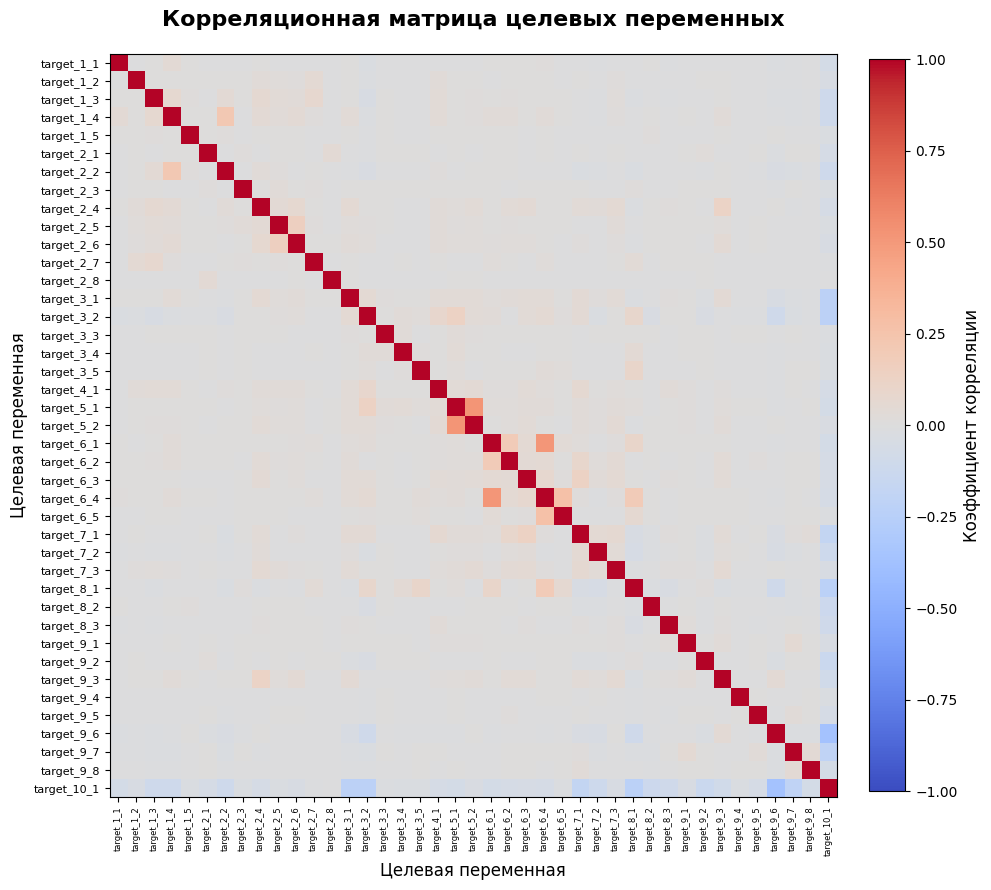

In [32]:
plt.figure(figsize=(10, 9))
im = plt.imshow(target_corr_matrix, cmap = 'coolwarm', vmin = -1, vmax = 1, aspect = 'auto')

cbar = plt.colorbar(im, fraction = 0.046, pad = 0.04)
cbar.set_label('Коэффициент корреляции', fontsize = 12)

plt.title("Корреляционная матрица целевых переменных", fontsize = 16, fontweight = 'bold', pad = 20)
plt.xlabel("Целевая переменная", fontsize = 12)
plt.ylabel("Целевая переменная", fontsize = 12)

plt.xticks(np.arange(len(target_columns)), target_columns, rotation = 90, fontsize = 6)
plt.yticks(np.arange(len(target_columns)), target_columns, fontsize = 8)

plt.tight_layout()
plt.show()

In [33]:
train_with_target.shape

(750000, 241)

Кажется, тут есть с чем можно работать.

- На первый взгляд, есть выделяющаяся target_10_1 с отрицательной корреляцией к остальным целевым переменным.
- Внутри целевых переменных с 3 по 7 группу есть заметная внутри-групповая корреляция.
- Небольшая корреляция есть и между целевыми переменными из 1 и 2 групп, в частности между target_1_4 и target_2_2.

В дальнейшей работе это все можно было бы учесть и покопать глубже. Но сейчас нужно подготовить решение :)
### Часть 2, обучаем Catboost

К счастью для нас, Catboost умеет "из коробки" работать и с пропусками, и (важно для нас) с multi-class и multi-label классификацией.

Попробуем обучить модель "в лоб", оставив более интересные возможности и надстройки для участников соревнования :)


##### Часть 2.1 подготовка данных

- Опустим сам customer_id
- Не забудем про ранее сохраненные категориальные признаки
- Найдем в документации Catboost настройку "MultiLogLoss"
- Будем осторожны в первом подходе к снаряду, так как деревьев будет строиться много

In [34]:
# Разделяем индексы
n = len(train_with_target)
train_idx = int(n * 0.8)

In [35]:
# Перемешиваем случайно
train_with_target = train_with_target.sample(fraction=1.0, seed=42)

# Разделяем на train и val
train_part = train_with_target[:train_idx]
val_part   = train_with_target[train_idx:]

In [36]:
# Разделяем признаки и таргеты
feature_cols = [c for c in train.columns if c != 'customer_id']
target_cols  = [c for c in target.columns if c != 'customer_id']

# Train
X_train = train_part.select(feature_cols).to_pandas()
y_train = train_part.select(target_cols).to_pandas()

# Validation
X_val = val_part.select(feature_cols).to_pandas()
y_val = val_part.select(target_cols).to_pandas()

ModuleNotFoundError: No module named 'pyarrow'

In [37]:
print(f"Train: {X_train.shape}, Val: {X_val.shape}")
print(f"Target train: {y_train.shape}, Target val: {y_val.shape}")

del train_part, val_part

NameError: name 'X_train' is not defined

In [38]:
train_pool = Pool(
    data=X_train,
    label=y_train,
    cat_features=cat_feature_names
)

val_pool = Pool(
    data=X_val,
    label=y_val,
    cat_features=cat_feature_names
)

NameError: name 'X_train' is not defined

In [39]:
model = CatBoostClassifier(
    iterations = 300,
    depth = 6,
    learning_rate = 0.1,
    loss_function = 'MultiLogloss',
    nan_mode = 'Min',
    random_seed = 42,

    task_type='GPU',
    verbose = 1
)

In [40]:
feature_cols = [c for c in train.columns if c != 'customer_id']
target_cols  = [c for c in target.columns if c != 'customer_id']

def cross_vall(df, model):
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    results = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(df)):
        # выделяем индексы
        train_df = df[train_idx]
        val_df = df[val_idx]

        # Train
        X_train = train_df.select(feature_cols).to_pandas()
        y_train = train_df.select(target_cols).to_pandas()

        # Validation
        X_val = val_df.select(feature_cols).to_pandas()
        y_val = val_df.select(target_cols).to_pandas()

        train_pool = Pool(
            data=X_train,
            label=y_train,
            cat_features=cat_feature_names
        )

        val_pool = Pool(
            data=X_val,
            label=y_val,
            cat_features=cat_feature_names
        )
        model.fit(train_pool)
        probas = model.predict_proba(val_pool)
        preds_val = np.array(probas)
        score = roc_auc_score(y_val.to_numpy(), preds_val, average='macro')
        results.append(score)
        print(f"Macro ROC-AUC: {score:.4f}")
    print(score)

In [ ]:
# cross_vall(train_with_target, model)

0:	learn: 0.4835522	total: 1.48s	remaining: 7m 22s
1:	learn: 0.3508727	total: 2.85s	remaining: 7m 4s
2:	learn: 0.2676609	total: 4.2s	remaining: 6m 56s
3:	learn: 0.2140173	total: 5.65s	remaining: 6m 58s
4:	learn: 0.1786651	total: 7.4s	remaining: 7m 16s
5:	learn: 0.1546897	total: 8.86s	remaining: 7m 14s
6:	learn: 0.1380977	total: 10.3s	remaining: 7m 9s
7:	learn: 0.1263588	total: 11.6s	remaining: 7m 4s
8:	learn: 0.1179099	total: 13s	remaining: 7m
9:	learn: 0.1115020	total: 14.5s	remaining: 6m 59s
10:	learn: 0.1068324	total: 15.9s	remaining: 6m 57s
11:	learn: 0.1034881	total: 17.3s	remaining: 6m 54s
12:	learn: 0.1008638	total: 18.7s	remaining: 6m 53s
13:	learn: 0.0987246	total: 20.5s	remaining: 6m 58s
14:	learn: 0.0970885	total: 21.9s	remaining: 6m 55s
15:	learn: 0.0958519	total: 23.3s	remaining: 6m 53s
16:	learn: 0.0948388	total: 24.7s	remaining: 6m 50s
17:	learn: 0.0940256	total: 26s	remaining: 6m 47s
18:	learn: 0.0933368	total: 27.4s	remaining: 6m 45s
19:	learn: 0.0927930	total: 28.8s	r

In [ ]:
model.fit(train_pool)

0:	learn: 0.4836730	total: 1.7s	remaining: 8m 27s
1:	learn: 0.3509524	total: 3.07s	remaining: 7m 37s
2:	learn: 0.2677553	total: 4.43s	remaining: 7m 18s
3:	learn: 0.2140754	total: 5.8s	remaining: 7m 9s
4:	learn: 0.1786883	total: 7.23s	remaining: 7m 6s
5:	learn: 0.1547053	total: 8.61s	remaining: 7m 2s
6:	learn: 0.1381085	total: 9.99s	remaining: 6m 58s
7:	learn: 0.1263644	total: 11.4s	remaining: 6m 55s
8:	learn: 0.1176160	total: 13s	remaining: 7m 1s
9:	learn: 0.1114886	total: 14.7s	remaining: 7m 6s
10:	learn: 0.1070068	total: 16.1s	remaining: 7m 2s
11:	learn: 0.1033837	total: 17.5s	remaining: 7m
12:	learn: 0.1008489	total: 18.9s	remaining: 6m 57s
13:	learn: 0.0988129	total: 20.3s	remaining: 6m 55s
14:	learn: 0.0972574	total: 21.7s	remaining: 6m 52s
15:	learn: 0.0958924	total: 23.2s	remaining: 6m 51s
16:	learn: 0.0948967	total: 24.5s	remaining: 6m 48s
17:	learn: 0.0940290	total: 26.3s	remaining: 6m 51s
18:	learn: 0.0933264	total: 27.8s	remaining: 6m 51s
19:	learn: 0.0927898	total: 29.1s	re

CatBoostClassifier(depth=6, iterations=300, learning_rate=0.1, loss_function='MultiLogloss', nan_mode='Min', random_seed=42, task_type='GPU', verbose=1)

In [ ]:
probas = model.predict_proba(val_pool)

In [ ]:
# Берём только prob_1 для каждого таргета
preds_val = np.array(probas)
# shape → (150_000, 41)
score = roc_auc_score(y_val.to_numpy(), preds_val, average='macro')
print(f"Macro ROC-AUC: {score:.4f}")

print("\nROC-AUC по каждому таргету:")
print(f"{'Таргет':<15} {'ROC-AUC':>10} {'Позитивных':>12} {'Сложность':>12}")
print("-" * 52)

Macro ROC-AUC: 0.8143

ROC-AUC по каждому таргету:
Таргет             ROC-AUC   Позитивных    Сложность
----------------------------------------------------


Видно что модель вприницпе устойчива на кросс-валидации и стабильно выдает 0.81 по ROC-AUC. Теперь проверим модель на каждому таргете

In [ ]:
y_val_np = y_val.to_numpy()

In [ ]:
# Подробный анализ по каждому таргету
results = []
for i, col in enumerate(target_cols):
    y_true = y_val_np[:, i]
    y_pred = preds_val[:, i]

    n_pos = int(y_true.sum())

    # Пропускаем если нет позитивных в val — модель не может быть оценена
    if n_pos == 0:
        print(f"⚠️  {col}: нет позитивных в val выборке!")
        continue

    auc     = roc_auc_score(y_true, y_pred)
    avg_prc = average_precision_score(y_true, y_pred)  # лучше для дисбаланса

    # Средние предсказанные вероятности
    mean_pred_pos = y_pred[y_true == 1].mean()  # для позитивных
    mean_pred_neg = y_pred[y_true == 0].mean()  # для негативных

    results.append({
        'target':        col,
        'n_positive':    n_pos,
        'ratio':         f"{int((len(y_true)-n_pos)/n_pos)}:1",
        'ROC_AUC':       round(auc, 4),
        'Avg_Precision': round(avg_prc, 4),
        'mean_prob_pos': round(mean_pred_pos, 4),  # хочем высокое
        'mean_prob_neg': round(mean_pred_neg, 4),  # хочем низкое
        'separation':    round(mean_pred_pos - mean_pred_neg, 4),  # разделение
    })

results_df = pl.DataFrame(results).sort('ROC_AUC')
print(results_df)

shape: (41, 8)
┌────────────┬────────────┬────────┬─────────┬─────────────┬─────────────┬────────────┬────────────┐
│ target     ┆ n_positive ┆ ratio  ┆ ROC_AUC ┆ Avg_Precisi ┆ mean_prob_p ┆ mean_prob_ ┆ separation │
│ ---        ┆ ---        ┆ ---    ┆ ---     ┆ on          ┆ os          ┆ neg        ┆ ---        │
│ str        ┆ i64        ┆ str    ┆ f64     ┆ ---         ┆ ---         ┆ ---        ┆ f64        │
│            ┆            ┆        ┆         ┆ f64         ┆ f64         ┆ f64        ┆            │
╞════════════╪════════════╪════════╪═════════╪═════════════╪═════════════╪════════════╪════════════╡
│ target_3_1 ┆ 14734      ┆ 9:1    ┆ 0.6752  ┆ 0.1808      ┆ 0.128       ┆ 0.0951     ┆ 0.0329     │
│ target_9_6 ┆ 33538      ┆ 3:1    ┆ 0.6777  ┆ 0.3509      ┆ 0.273       ┆ 0.2089     ┆ 0.0641     │
│ target_9_3 ┆ 2773       ┆ 53:1   ┆ 0.6849  ┆ 0.0442      ┆ 0.0278      ┆ 0.0185     ┆ 0.0094     │
│ target_6_1 ┆ 1302       ┆ 114:1  ┆ 0.7166  ┆ 0.0229      ┆ 0.0158      ┆ 0

In [ ]:
with pl.Config(tbl_rows=200, tbl_cols=40):
    print(results_df)

shape: (41, 8)
┌─────────────┬────────────┬────────┬─────────┬─────────────┬────────────┬────────────┬────────────┐
│ target      ┆ n_positive ┆ ratio  ┆ ROC_AUC ┆ Avg_Precisi ┆ mean_prob_ ┆ mean_prob_ ┆ separation │
│ ---         ┆ ---        ┆ ---    ┆ ---     ┆ on          ┆ pos        ┆ neg        ┆ ---        │
│ str         ┆ i64        ┆ str    ┆ f64     ┆ ---         ┆ ---        ┆ ---        ┆ f64        │
│             ┆            ┆        ┆         ┆ f64         ┆ f64        ┆ f64        ┆            │
╞═════════════╪════════════╪════════╪═════════╪═════════════╪════════════╪════════════╪════════════╡
│ target_3_1  ┆ 14734      ┆ 9:1    ┆ 0.6752  ┆ 0.1808      ┆ 0.128      ┆ 0.0951     ┆ 0.0329     │
│ target_9_6  ┆ 33538      ┆ 3:1    ┆ 0.6777  ┆ 0.3509      ┆ 0.273      ┆ 0.2089     ┆ 0.0641     │
│ target_9_3  ┆ 2773       ┆ 53:1   ┆ 0.6849  ┆ 0.0442      ┆ 0.0278     ┆ 0.0185     ┆ 0.0094     │
│ target_6_1  ┆ 1302       ┆ 114:1  ┆ 0.7166  ┆ 0.0229      ┆ 0.0158     ┆ 0

Судя по всем таргеты, у которых большое кол-во положительных классов, оказалиьс более зашумлены, чем у таргетов с меньшим кол-вом, хотя будто все это полочилось за счет частого угадывания наиболее частой метки (0), хотя были найдены и некоторые положительные метки, что говорит, что модель может их находить.\
Но в целом ROC-AUC 0.81 получился за счет частого указывания 0

### Часть 3, подготовка сабмита

Посмотрим на пример рабочего бейзлайн решения.

Именно в таком формате платформа ждет от нас решения:

In [ ]:
sample_submit = pl.read_parquet('sample_submit.parquet')
sample_submit.head(n = 5)

customer_id,predict_1_1,predict_1_2,predict_1_3,predict_1_4,predict_1_5,predict_2_1,predict_2_2,predict_2_3,predict_2_4,predict_2_5,predict_2_6,predict_2_7,predict_2_8,predict_3_1,predict_3_2,predict_3_3,predict_3_4,predict_3_5,predict_4_1,predict_5_1,predict_5_2,predict_6_1,predict_6_2,predict_6_3,predict_6_4,predict_6_5,predict_7_1,predict_7_2,predict_7_3,predict_8_1,predict_8_2,predict_8_3,predict_9_1,predict_9_2,predict_9_3,predict_9_4,predict_9_5,predict_9_6,predict_9_7,predict_9_8,predict_10_1
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1750001,-4.559634,-5.490853,-3.682293,-3.696798,-6.377251,-4.698343,-3.925055,-6.864407,-4.644582,-6.041761,-5.306951,-8.498892,-10.326492,-2.117544,-3.225609,-6.416635,-7.057265,-9.00383,-4.980861,-4.800834,-5.807614,-4.759972,-4.719907,-5.224776,-5.52965,-8.442456,-2.790907,-3.40613,-5.383466,-3.463931,-3.20201,-3.96947,-5.522536,-2.835501,-3.592803,-5.626597,-4.600432,-0.826411,-2.292409,-4.566064,-0.624437
1750002,-4.525017,-5.424643,-3.600475,-3.663936,-6.481639,-4.698258,-3.87817,-6.936742,-4.645305,-6.135729,-5.380085,-8.337462,-10.183376,-2.203137,-3.597962,-6.640242,-7.668241,-9.528925,-5.153873,-4.985227,-5.928929,-4.757343,-4.775738,-5.236387,-5.556886,-8.324126,-2.859017,-3.515063,-5.523479,-3.379077,-3.198607,-3.882064,-5.586788,-2.723239,-3.643311,-5.593574,-4.575498,-0.778346,-2.265025,-4.476992,-0.654095
1750003,-4.236281,-5.217968,-3.718711,-3.652767,-6.019878,-5.293401,-3.742374,-7.368946,-4.510376,-6.034828,-5.158191,-9.000582,-10.222584,-2.262793,-3.455289,-6.670321,-7.669997,-9.098556,-5.156947,-4.889535,-5.912771,-4.659181,-4.814485,-5.226197,-5.420546,-8.381626,-2.971064,-3.012568,-5.33779,-3.654234,-3.037381,-3.915707,-5.821074,-3.501836,-3.764656,-5.877993,-5.007001,-1.049139,-2.805007,-5.363468,-0.362334
1750004,-5.107494,-5.747457,-3.87031,-3.988364,-6.613195,-4.781696,-4.434008,-7.223677,-4.649338,-6.461804,-5.293109,-8.814394,-9.972295,-2.315931,-3.816451,-6.643194,-8.339884,-10.589949,-5.334445,-4.888459,-5.859745,-4.840233,-4.480154,-4.971953,-5.841156,-9.015239,-2.464894,-3.341553,-5.357212,-4.255379,-3.26839,-4.015814,-5.678406,-2.961717,-3.568433,-5.278345,-4.324995,-0.696825,-2.157653,-4.039829,-0.652303
1750005,-4.48209,-5.395573,-3.571668,-3.641002,-6.268344,-4.670509,-3.762274,-6.943392,-4.550145,-6.070182,-5.286359,-8.725736,-10.104682,-2.229007,-3.662391,-6.55999,-7.705663,-9.952746,-5.139228,-4.917467,-5.864986,-4.77367,-4.696359,-5.208519,-5.754242,-8.778719,-2.784675,-3.323991,-5.338707,-3.977604,-3.055069,-3.632175,-5.412687,-2.838579,-3.566938,-5.623631,-4.54547,-0.736783,-2.24171,-4.585213,-0.668844


Сперва стоит сделать предсказания с помощью Catboost-а на тестовых данных. А для этого к ним стоит не забыть применить все те же манипуляции, что мы делали и с тренировочными данными (до обучения Catboost-а).

In [ ]:
test.head(n = 5)
test = test.with_columns(
    pl.col(cat_feature_names).cast(pl.Int32)
)
test_pool = Pool(data = test.drop("customer_id").to_pandas(),
                 cat_features = cat_feature_names)


In [ ]:
# Делаем предсказания обученной ранее моделью.
# Предсказания будут в форме numpy.ndarray в 41 столбец.
test_predict = model.predict(test_pool, prediction_type = "RawFormulaVal")
test_predict.shape

(250000, 41)

In [ ]:
# Пойдем по долгому пути и сами соберем свой submit файл.
predict_schema = [col.replace("target_", "predict_") for col in target.columns if col.startswith("target_")]

In [ ]:
catboost_predictions = pl.DataFrame(test_predict, schema = predict_schema)
catboost_predictions.head(n = 5)

predict_1_1,predict_1_2,predict_1_3,predict_1_4,predict_1_5,predict_2_1,predict_2_2,predict_2_3,predict_2_4,predict_2_5,predict_2_6,predict_2_7,predict_2_8,predict_3_1,predict_3_2,predict_3_3,predict_3_4,predict_3_5,predict_4_1,predict_5_1,predict_5_2,predict_6_1,predict_6_2,predict_6_3,predict_6_4,predict_6_5,predict_7_1,predict_7_2,predict_7_3,predict_8_1,predict_8_2,predict_8_3,predict_9_1,predict_9_2,predict_9_3,predict_9_4,predict_9_5,predict_9_6,predict_9_7,predict_9_8,predict_10_1
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
-7.320116,-6.095465,-4.563058,-4.49865,-7.313731,-4.772443,-5.447983,-7.510222,-4.685999,-6.501346,-5.840006,-9.61444,-11.273992,-2.450506,-4.494972,-8.005163,-9.949067,-12.571711,-4.947816,-5.835972,-6.406953,-6.342165,-5.922132,-5.338287,-6.713385,-9.66322,-3.189059,-4.639718,-5.528553,-5.644841,-3.828498,-3.755822,-5.418074,-2.466494,-3.547164,-9.738108,-6.738233,-0.569739,-2.182319,-7.462541,-0.55271
-5.223284,-5.215512,-3.15439,-4.092259,-5.800607,-3.643916,-4.077133,-7.590095,-4.490642,-5.681735,-5.81342,-7.823175,-11.884172,-2.66097,-5.193571,-7.205662,-9.559496,-11.722687,-6.28797,-5.510965,-6.727514,-5.978902,-5.173057,-5.955476,-6.198252,-9.69367,-3.283497,-4.577729,-6.373081,-3.687495,-2.518649,-4.943257,-6.44037,-1.306106,-3.599905,-5.819558,-3.968541,-0.79572,-2.279613,-9.533846,-1.216777
-6.092821,-5.807618,-4.554525,-3.869878,-5.590337,-6.130801,-4.80496,-7.574609,-5.523111,-6.282239,-5.443676,-11.532457,-13.680444,-2.249613,-3.936663,-7.86411,-8.553326,-11.60519,-4.39581,-5.079876,-8.072955,-5.18813,-6.29405,-6.28569,-5.739681,-9.896672,-4.353537,-3.524608,-6.055725,-3.376916,-3.577894,-4.371388,-5.774793,-4.01838,-4.265656,-9.889524,-7.832693,-1.500349,-3.356724,-6.826691,-0.119655
-7.165712,-7.207492,-5.254512,-4.97228,-9.295994,-5.059281,-6.17988,-8.195158,-4.605044,-7.868719,-6.098617,-10.037698,-11.92539,-2.636658,-4.395839,-7.960248,-10.14731,-12.750522,-6.348262,-5.823166,-6.758556,-5.828396,-4.947926,-5.403701,-6.919702,-11.415038,-2.811848,-4.310049,-5.789603,-5.506242,-4.305117,-4.343512,-6.137698,-3.205097,-3.780357,-6.529796,-4.575016,-0.459171,-2.066555,-6.560368,-0.614762
-4.273316,-5.95816,-3.559343,-3.52417,-7.470371,-4.813569,-4.656813,-6.96454,-5.292306,-5.545608,-5.221417,-9.306101,-12.921906,-1.883018,-4.745558,-7.33107,-8.954652,-14.087511,-7.784589,-6.041302,-6.399051,-4.768029,-5.038148,-7.092138,-6.689719,-12.468131,-5.270621,-4.287088,-6.183987,-4.879529,-3.541798,-4.611362,-6.294886,-2.622895,-3.548336,-7.078828,-4.449034,-0.9731,-2.263982,-8.14744,-0.793519


In [ ]:
submit = test.select("customer_id")
submit = submit.hstack(catboost_predictions)
submit.head(n = 5)

customer_id,predict_1_1,predict_1_2,predict_1_3,predict_1_4,predict_1_5,predict_2_1,predict_2_2,predict_2_3,predict_2_4,predict_2_5,predict_2_6,predict_2_7,predict_2_8,predict_3_1,predict_3_2,predict_3_3,predict_3_4,predict_3_5,predict_4_1,predict_5_1,predict_5_2,predict_6_1,predict_6_2,predict_6_3,predict_6_4,predict_6_5,predict_7_1,predict_7_2,predict_7_3,predict_8_1,predict_8_2,predict_8_3,predict_9_1,predict_9_2,predict_9_3,predict_9_4,predict_9_5,predict_9_6,predict_9_7,predict_9_8,predict_10_1
i32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1750001,-7.320116,-6.095465,-4.563058,-4.49865,-7.313731,-4.772443,-5.447983,-7.510222,-4.685999,-6.501346,-5.840006,-9.61444,-11.273992,-2.450506,-4.494972,-8.005163,-9.949067,-12.571711,-4.947816,-5.835972,-6.406953,-6.342165,-5.922132,-5.338287,-6.713385,-9.66322,-3.189059,-4.639718,-5.528553,-5.644841,-3.828498,-3.755822,-5.418074,-2.466494,-3.547164,-9.738108,-6.738233,-0.569739,-2.182319,-7.462541,-0.55271
1750002,-5.223284,-5.215512,-3.15439,-4.092259,-5.800607,-3.643916,-4.077133,-7.590095,-4.490642,-5.681735,-5.81342,-7.823175,-11.884172,-2.66097,-5.193571,-7.205662,-9.559496,-11.722687,-6.28797,-5.510965,-6.727514,-5.978902,-5.173057,-5.955476,-6.198252,-9.69367,-3.283497,-4.577729,-6.373081,-3.687495,-2.518649,-4.943257,-6.44037,-1.306106,-3.599905,-5.819558,-3.968541,-0.79572,-2.279613,-9.533846,-1.216777
1750003,-6.092821,-5.807618,-4.554525,-3.869878,-5.590337,-6.130801,-4.80496,-7.574609,-5.523111,-6.282239,-5.443676,-11.532457,-13.680444,-2.249613,-3.936663,-7.86411,-8.553326,-11.60519,-4.39581,-5.079876,-8.072955,-5.18813,-6.29405,-6.28569,-5.739681,-9.896672,-4.353537,-3.524608,-6.055725,-3.376916,-3.577894,-4.371388,-5.774793,-4.01838,-4.265656,-9.889524,-7.832693,-1.500349,-3.356724,-6.826691,-0.119655
1750004,-7.165712,-7.207492,-5.254512,-4.97228,-9.295994,-5.059281,-6.17988,-8.195158,-4.605044,-7.868719,-6.098617,-10.037698,-11.92539,-2.636658,-4.395839,-7.960248,-10.14731,-12.750522,-6.348262,-5.823166,-6.758556,-5.828396,-4.947926,-5.403701,-6.919702,-11.415038,-2.811848,-4.310049,-5.789603,-5.506242,-4.305117,-4.343512,-6.137698,-3.205097,-3.780357,-6.529796,-4.575016,-0.459171,-2.066555,-6.560368,-0.614762
1750005,-4.273316,-5.95816,-3.559343,-3.52417,-7.470371,-4.813569,-4.656813,-6.96454,-5.292306,-5.545608,-5.221417,-9.306101,-12.921906,-1.883018,-4.745558,-7.33107,-8.954652,-14.087511,-7.784589,-6.041302,-6.399051,-4.768029,-5.038148,-7.092138,-6.689719,-12.468131,-5.270621,-4.287088,-6.183987,-4.879529,-3.541798,-4.611362,-6.294886,-2.622895,-3.548336,-7.078828,-4.449034,-0.9731,-2.263982,-8.14744,-0.793519


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path = "/content/drive/MyDrive/base_line_solution_0.parquet"
submit.write_parquet(path)